# Used Car Price Prediction

## 1. Libraries and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("car details v4.csv")

df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


## 2. Inspecting the Dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

In [4]:
df.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


In [5]:
df.isnull().sum()

Make                    0
Model                   0
Price                   0
Year                    0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
dtype: int64

## 3. Select Features and Target

In [6]:
# Extract numeric values from Engine, Max Power, Max Torque
df["Engine_cc"] = df["Engine"].str.extract(r"(\d+)").astype(float)
df["Power_bhp"] = df["Max Power"].str.extract(r"([\d.]+)").astype(float)
df["Torque_Nm"] = df["Max Torque"].str.extract(r"([\d.]+)").astype(float)

df[["Engine", "Engine_cc", "Max Power", "Power_bhp", "Max Torque", "Torque_Nm"]].head()

,Engine,Engine_cc,Max Power,Power_bhp,Max Torque,Torque_Nm
0,1198 cc,1198.0,87 bhp @ 6000 rpm,87.0,109 Nm @ 4500 rpm,109.0000
1,1248 cc,1248.0,74 bhp @ 4000 rpm,74.0,190 Nm @ 2000 rpm,190.0000
2,1197 cc,1197.0,79 bhp @ 6000 rpm,79.0,112.7619 Nm @ 4000 rpm,112.7619
3,1197 cc,1197.0,82 bhp @ 6000 rpm,82.0,113 Nm @ 4200 rpm,113.0000
4,2393 cc,2393.0,148 bhp @ 3400 rpm,148.0,343 Nm @ 1400 rpm,343.0000


In [7]:
# Convert Year into car age (more predictive than raw year)
df["Age"] = 2026 - df["Year"]

df[["Year", "Age"]].head()

,Year,Age
0,2017,9
1,2014,12
2,2011,15
3,2019,7
4,2018,8


In [8]:
features = [
    "Make",
    "Model",
    "Age",
    "Kilometer",
    "Fuel Type",
    "Transmission",
    "Location",
    "Owner",
    "Seller Type",
    "Length",
    "Width",
    "Height",
    "Seating Capacity",
    "Fuel Tank Capacity",
    "Engine_cc",
    "Power_bhp",
    "Torque_Nm",
]
X = df[features]
y = df["Price"]

X.head()

,Make,Model,Age,Kilometer,Fuel Type,Transmission,Location,Owner,Seller Type,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Engine_cc,Power_bhp,Torque_Nm
0,Honda,Amaze 1.2 VX i-VTEC,9,87150,Petrol,Manual,Pune,First,Corporate,3990.0,1680.0,1505.0,5.0,35.0,1198.0,87.0,109.0000
1,Maruti Suzuki,Swift DZire VDI,12,75000,Diesel,Manual,Ludhiana,Second,Individual,3995.0,1695.0,1555.0,5.0,42.0,1248.0,74.0,190.0000
2,Hyundai,i10 Magna 1.2 Kappa2,15,67000,Petrol,Manual,Lucknow,First,Individual,3585.0,1595.0,1550.0,5.0,35.0,1197.0,79.0,112.7619
3,Toyota,Glanza G,7,37500,Petrol,Manual,Mangalore,First,Individual,3995.0,1745.0,1510.0,5.0,37.0,1197.0,82.0,113.0000
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],8,69000,Diesel,Manual,Mumbai,First,Individual,4735.0,1830.0,1795.0,7.0,55.0,2393.0,148.0,343.0000


In [9]:
numeric_features = [
    "Age",
    "Kilometer",
    "Length",
    "Width",
    "Height",
    "Seating Capacity",
    "Fuel Tank Capacity",
    "Engine_cc",
    "Power_bhp",
    "Torque_Nm",
]

categorical_features = [
    "Make",
    "Model",
    "Fuel Type",
    "Transmission",
    "Location",
    "Owner",
    "Seller Type"
]

## 4. Data Preprocessing

In [10]:
# Fill missing numeric values with the median
# Fill missing categorical values with the most common value
# One-hot encode categorical columns
numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 5. Train/Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape

((1647, 17), (412, 17))

## 6. Linear Regression Model

In [12]:
y_train_log = np.log(y_train)


In [13]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['Make','Model','Age',...,'Engine_cc','Power_bhp','Torque_Nm']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis co

## 7. Predictions

In [14]:
y_pred = np.exp(model.predict(X_test))

y_pred[:10]

array([3831896.72917738,  751024.43930469,  507797.95498083,
       1057153.34020642,  604657.1145052 ,  299348.25917424,
       1080877.8186224 , 1663812.40701039, 1537203.43953843,
       5800703.35245199])

## 8. Evaluation

In [15]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 413967.9707917687
Root Mean Squared Error: 903435.1668804027
R² Score: 0.8831717530645029


In [16]:
pct_error = np.abs(y_pred - y_test) / y_test
within_15pct = (pct_error <= 0.15).mean()
print(f"{within_15pct:.1%} of predictions are within ±15% of the actual price")

44.9% of predictions are within ±15% of the actual price


## 9. Interpret Model Performance

In [17]:
print("Model Performance Summary")
print("-------------------------")
print(f"Mean Absolute Error: {mae:,.2f}")
print(f"Root Mean Squared Error: {rmse:,.2f}")
print(f"R² Score: {r2:.3f}")

if r2 >= 0.7:
    print("The model explains a strong amount of price variation.")
elif r2 >= 0.4:
    print("The model explains a moderate amount of price variation.")
else:
    print("The model explains a low amount of price variation.")

Model Performance Summary
-------------------------
Mean Absolute Error: 413,967.97
Root Mean Squared Error: 903,435.17
R² Score: 0.883
The model explains a strong amount of price variation.


## 10. Compare Actual vs Predicted Prices

In [18]:
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

results.head(10)

,Actual Price,Predicted Price
1298,4800000,3.831897e+06
591,825000,7.510244e+05
1318,695000,5.077980e+05
1067,950000,1.057153e+06
29,819999,6.046571e+05
1058,310000,2.993483e+05
712,1000000,1.080878e+06
453,1998999,1.663812e+06
1646,850000,1.537203e+06
757,3950000,5.800703e+06


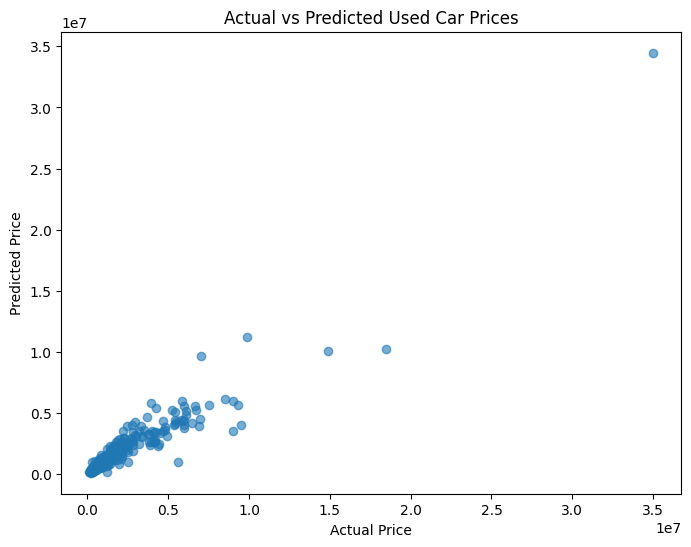

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Used Car Prices")

plt.show()

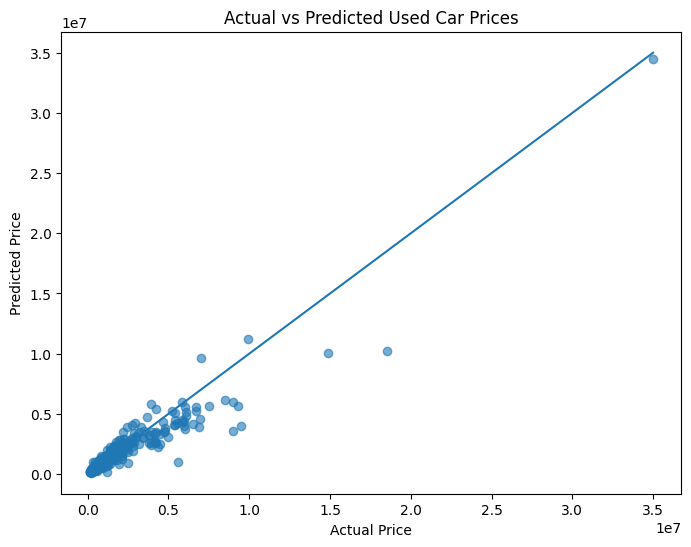

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot([min_price, max_price], [min_price, max_price])

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Used Car Prices")

plt.show()

The log-transformed Linear Regression model achieves an R² of 0.88 on the test set, with predictions tracking actual prices closely for lower and mid-range cars but spreading more at the high end. However, only 44.9% of predictions fall within the ±15% pricing tolerance, suggesting the model is a solid first-pass estimator but likely needs human review before supporting fully automated instant-buy pricing.